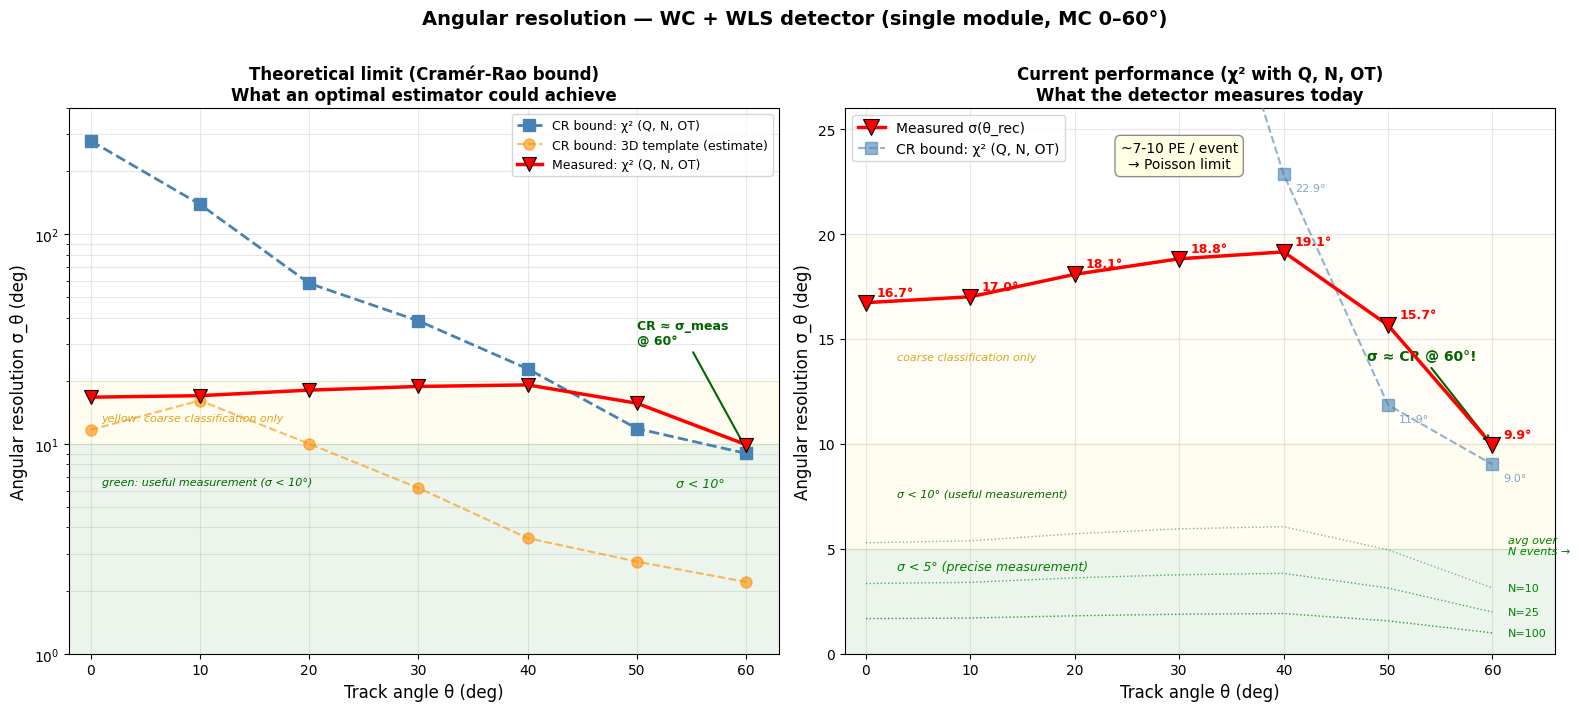

Plot saved: summary_angular_resolution.png


In [4]:
# %% [markdown]
# # Summary plot: angular resolution vs theta
#
# Comparison of all methods: CR bound (theoretical limit)
# and measured performance from closure test.

# %%
import numpy as np
import matplotlib.pyplot as plt

# ─── Data ───

theta_points = np.array([0, 10, 20, 30, 40, 50, 60])

# CR bound — chi2 with 3 features (Q, N_peaks, OT)
cr_3feat = np.array([279.47, 139.11, 58.42, 38.70, 22.85, 11.86, 9.02])

# CR bound template matching (extended to 60° with log-log extrapolation)
cr_tmpl_3d = np.array([11.69, 16.13, 10.03, 6.17, 3.56, 2.75, 2.20])

# Measured performance — chi2 with 3 features (includes 60°)
sigma_real = np.array([16.73, 17.01, 18.08, 18.82, 19.15, 15.66, 9.93])

# ─── Main figure ───
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# === Left panel: CR bound (log scale) ===
ax = axes[0]
ax.semilogy(theta_points, cr_3feat, 's--', color='steelblue', markersize=8,
            linewidth=2, label='CR bound: χ² (Q, N, OT)', zorder=3)
ax.semilogy(theta_points, cr_tmpl_3d, 'o--', color='darkorange', markersize=8,
            linewidth=1.5, alpha=0.6, label='CR bound: 3D template (estimate)', zorder=3)
ax.semilogy(theta_points, sigma_real, 'v-', color='red', markersize=10,
            linewidth=2.5, markeredgecolor='black', markeredgewidth=0.8,
            label='Measured: χ² (Q, N, OT)', zorder=5)

# Annotation: convergence at 60°
ax.annotate('CR ≈ σ_meas\n@ 60°', xy=(60, 9.5), xytext=(50, 30),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
            fontsize=9, color='darkgreen', fontweight='bold')

# Coloured bands
ax.axhspan(0, 10, alpha=0.08, color='green', zorder=0)
ax.text(58, 7, 'σ < 10°', fontsize=9, color='green', ha='right',
        va='top', fontstyle='italic')
ax.axhspan(10, 20, alpha=0.06, color='gold', zorder=0)

ax.set_xlabel('Track angle θ (deg)', fontsize=12)
ax.set_ylabel('Angular resolution σ_θ (deg)', fontsize=12)
ax.set_title('Theoretical limit (Cramér-Rao bound)\nWhat an optimal estimator could achieve',
             fontsize=12, fontweight='bold')
ax.set_xlim(-2, 63)
ax.set_ylim(1, 400)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, which='both')

# Band labels
ax.text(1, 7, 'green: useful measurement (σ < 10°)', fontsize=8,
        color='darkgreen', fontstyle='italic', va='top')
ax.text(1, 14, 'yellow: coarse classification only', fontsize=8,
        color='goldenrod', fontstyle='italic', va='top')


# === Right panel: measured performance ===
ax = axes[1]

ax.plot(theta_points, sigma_real, 'v-', color='red', markersize=12,
        linewidth=2.5, markeredgecolor='black', markeredgewidth=0.8,
        label='Measured σ(θ_rec)', zorder=5)
for x, y in zip(theta_points, sigma_real):
    ax.annotate(f'{y:.1f}°', (x, y), textcoords='offset points',
                xytext=(8, 5), fontsize=9, fontweight='bold', color='red')

ax.plot(theta_points, cr_3feat, 's--', color='steelblue', markersize=8,
        linewidth=1.5, alpha=0.6, label='CR bound: χ² (Q, N, OT)', zorder=3)
for x, y in zip(theta_points, cr_3feat):
    if y < 30:
        ax.annotate(f'{y:.1f}°', (x, y), textcoords='offset points',
                    xytext=(8, -12), fontsize=8, color='steelblue', alpha=0.7)

# Average over N events
for N, alpha_val in [(10, 0.5), (25, 0.65), (100, 0.8)]:
    sigma_avg = sigma_real / np.sqrt(N)
    ax.plot(theta_points, sigma_avg, ':', color='green', linewidth=1,
            alpha=alpha_val)
    ax.text(61.5, sigma_avg[-1], f'N={N}', fontsize=8, color='green', va='center')

ax.text(61.5, sigma_real[-1]/np.sqrt(10) + 1.5, 'avg over\nN events →',
        fontsize=8, color='green', va='bottom', ha='left', fontstyle='italic')

# Coloured bands
ax.axhspan(0, 5, alpha=0.08, color='green', zorder=0)
ax.text(3, 4, 'σ < 5° (precise measurement)', fontsize=9,
        color='green', fontstyle='italic')
ax.axhspan(5, 10, alpha=0.06, color='gold', zorder=0)
ax.text(3, 7.5, 'σ < 10° (useful measurement)', fontsize=8,
        color='darkgreen', fontstyle='italic')
ax.axhspan(10, 20, alpha=0.04, color='gold', zorder=0)
ax.text(3, 14, 'coarse classification only', fontsize=8,
        color='goldenrod', fontstyle='italic')

# Annotations
ax.text(30, 23,
        '~7-10 PE / event\n→ Poisson limit',
        fontsize=10, ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.9))
ax.annotate('σ ≈ CR @ 60°!', xy=(60, 9.93), xytext=(48, 14),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Track angle θ (deg)', fontsize=12)
ax.set_ylabel('Angular resolution σ_θ (deg)', fontsize=12)
ax.set_title('Current performance (χ² with Q, N, OT)\nWhat the detector measures today',
             fontsize=12, fontweight='bold')
ax.set_xlim(-2, 66)
ax.set_ylim(0, 26)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

fig.suptitle('Angular resolution — WC + WLS detector (single module, MC 0–60°)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('summary_angular_resolution.png', dpi=200,
            bbox_inches='tight')
plt.show()
print("Plot saved: summary_angular_resolution.png")